In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_squared_error

In [9]:
df = pd.read_csv("/content/BTC-USD_stock_data.csv")

In [10]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-01-01,963.658020,1003.080017,958.698975,998.325012,998.325012,147775008
1,2017-01-02,998.617004,1031.390015,996.702026,1021.750000,1021.750000,222184992
2,2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,1043.839966,185168000
3,2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,1154.729980,344945984
4,2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,1013.380005,510199008


In [11]:
df = df.set_index("Date")

In [12]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-01-01,963.658020,1003.080017,958.698975,998.325012,998.325012,147775008
2017-01-02,998.617004,1031.390015,996.702026,1021.750000,1021.750000,222184992
2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,1043.839966,185168000
2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,1154.729980,344945984
2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,1013.380005,510199008


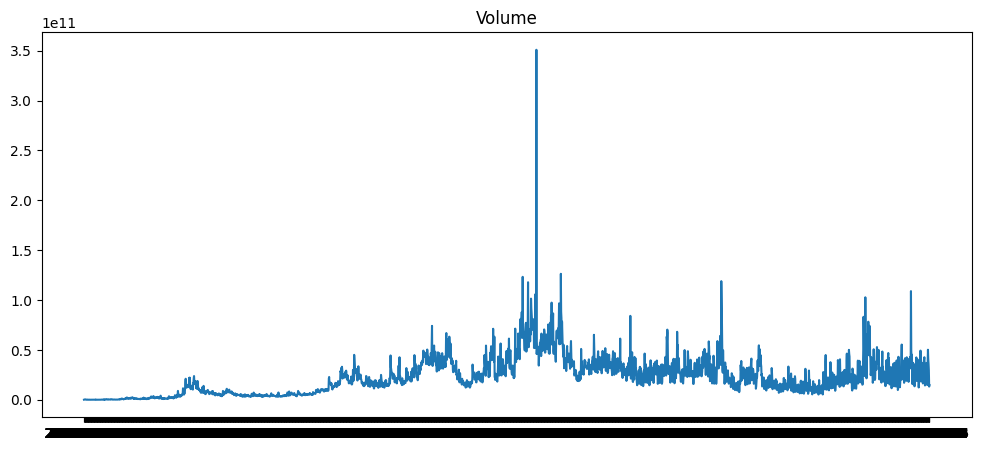

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df['Volume'])
plt.title("Volume")
plt.show()

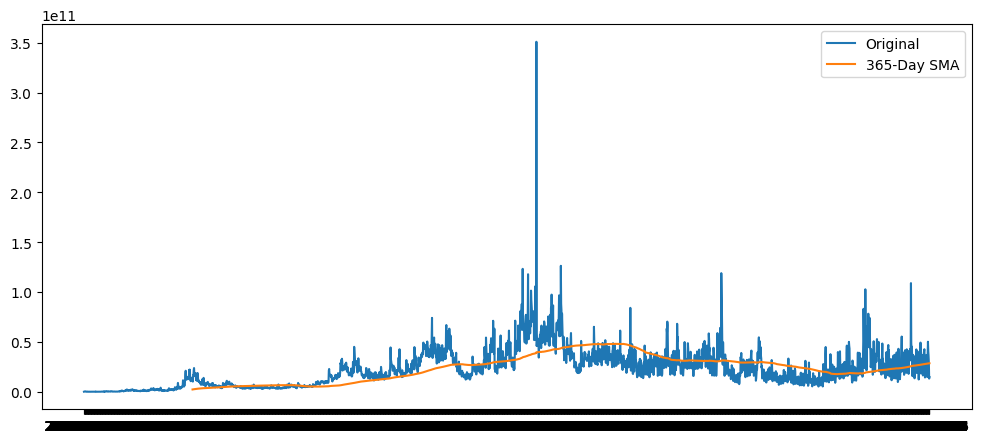

In [16]:
df['SMA_365'] = df['Volume'].rolling(window=365).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Volume'], label='Original')
plt.plot(df['SMA_365'], label='365-Day SMA')
plt.legend()
plt.show()

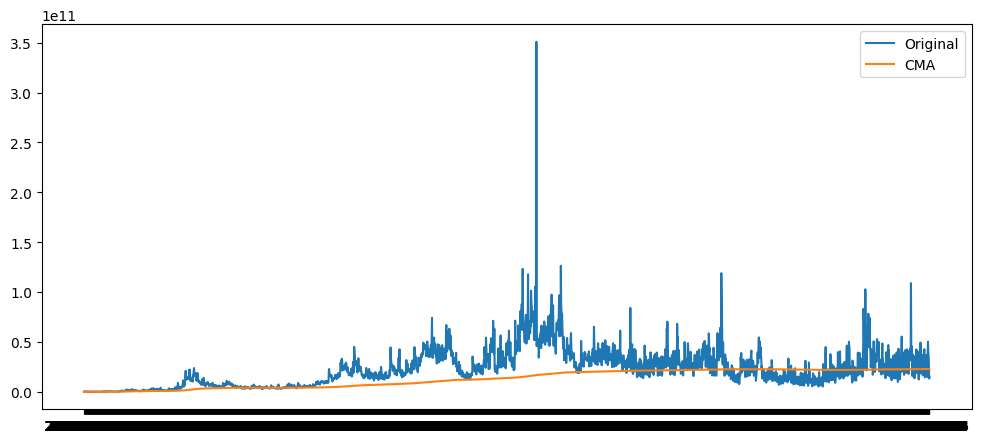

In [17]:
df['CMA'] = df['Volume'].expanding().mean()

plt.figure(figsize=(12,5))
plt.plot(df['Volume'], label='Original')
plt.plot(df['CMA'], label='CMA')
plt.legend()
plt.show()

In [18]:
df.head(20)

,Open,High,Low,Close,Adj Close,Volume,SMA_7,SMA_365,CMA
Date,,,,,,,,,
2017-01-01,963.658020,1003.080017,958.698975,998.325012,998.325012,147775008,NaN,NaN,1.477750e+08
2017-01-02,998.617004,1031.390015,996.702026,1021.750000,1021.750000,222184992,NaN,NaN,1.849800e+08
2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,1043.839966,185168000,NaN,NaN,1.850427e+08
2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,1154.729980,344945984,NaN,NaN,2.250185e+08
2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,1013.380005,510199008,NaN,NaN,2.820546e+08
2017-01-06,1014.239990,1046.810059,883.943970,902.200989,902.200989,351876000,NaN,NaN,2.936915e+08
2017-01-07,903.487000,908.585022,823.556030,908.585022,908.585022,279550016,2.916713e+08,NaN,2.916713e+08
2017-01-08,908.174988,942.723999,887.249023,911.198975,911.198975,158715008,2.932341e+08,NaN,2.750518e+08
2017-01-09,913.244019,913.685974,879.807007,902.828003,902.828003,141876992,2.817616e+08,NaN,2.602546e+08


Staitionarity


In [20]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    series = series.dropna()   # IMPORTANT
    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print(" Data is Stationary")
    else:
        print(" Data is NOT Stationary")

adf_test(df['Volume'])

ADF Statistic: -2.591126298586605
p-value: 0.09484518559072658
 Data is NOT Stationary


Its a non stationary data as p value greater than 0.05

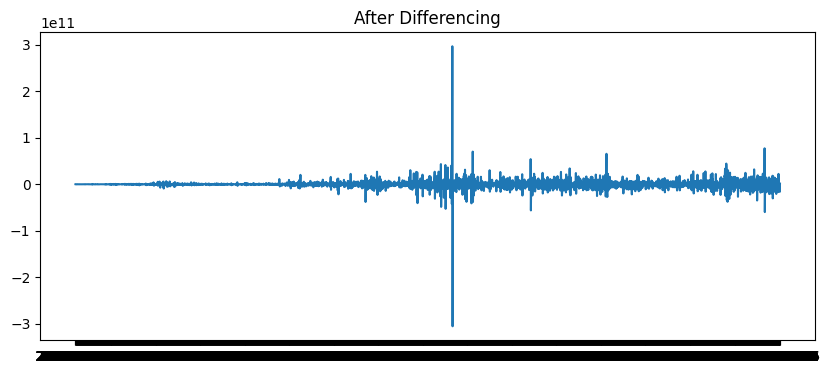

ADF Statistic: -13.973029214078364
p-value: 4.310873146256819e-26
 Data is Stationary


In [21]:
df['diff'] = df['Volume'].diff()

plt.figure(figsize=(10,4))
plt.plot(df['diff'])
plt.title("After Differencing")
plt.show()

adf_test(df['diff'])

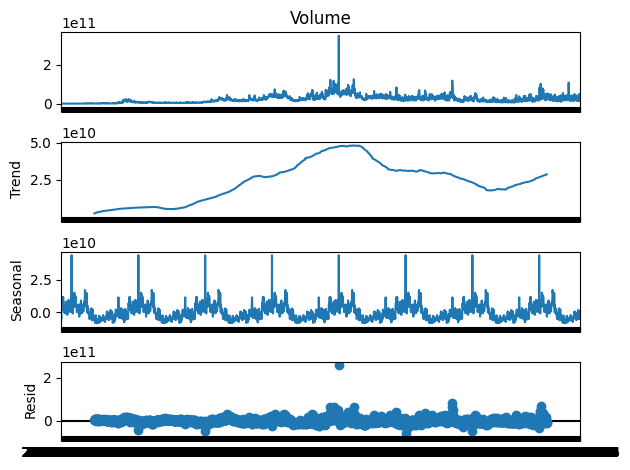

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Volume'], model='additive', period=365)
decomposition.plot()
plt.show()

<Figure size 1000x400 with 0 Axes>

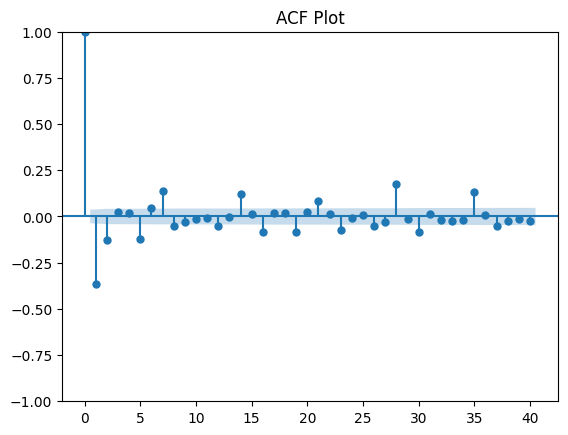

In [24]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df['diff'].dropna(), lags=40)
plt.title("ACF Plot")
plt.show()

<Figure size 1000x400 with 0 Axes>

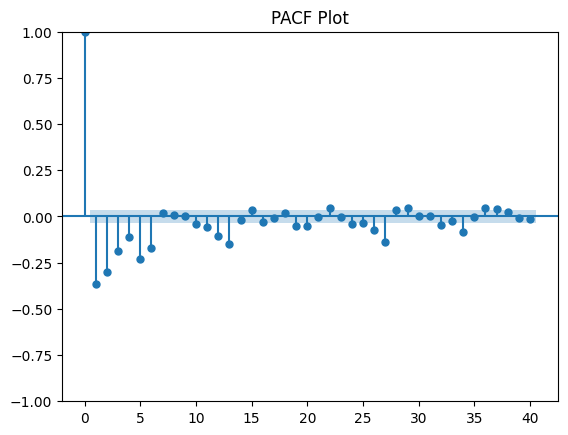

In [25]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,4))
plot_pacf(df['diff'].dropna(), lags=40)
plt.title("PACF Plot")
plt.show()

In [27]:
split = int(len(df) * 0.8)

train = df['Volume'][:split]
test = df['Volume'][split:]

#ARIMA MODEL

In [28]:
model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


#SARIMA MODEL

In [29]:
model_sarima= SARIMAX(train,
                order=(2,1,2),
                seasonal_order=(1,1,1,7))

model_sarima_fit = model_sarima.fit()

pred_sarima = model_sarima_fit.forecast(len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [30]:
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 19208039263.84361
SARIMA RMSE: 27014082416.680664


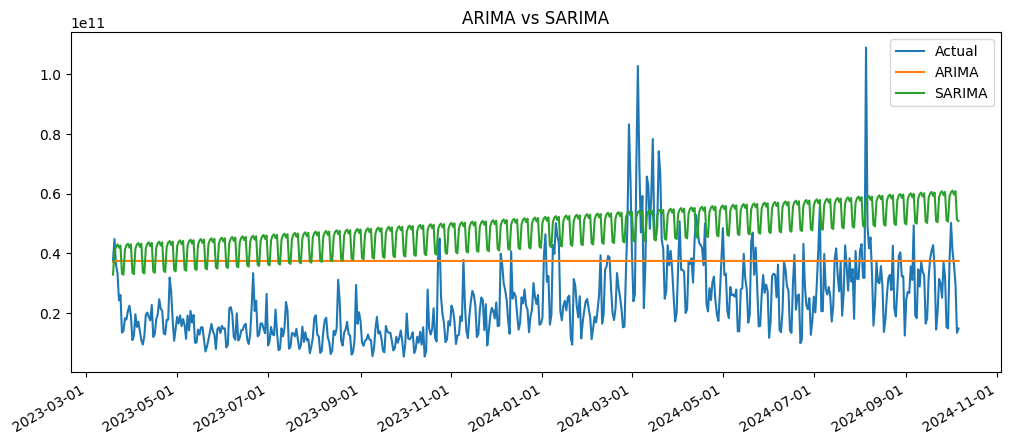

In [36]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
ax = plt.gca() # Get the current axes

# Convert DatetimeIndex to matplotlib's internal numerical format
ax.plot(mdates.date2num(test.index), test.values, label='Actual')
ax.plot(mdates.date2num(pred_arima.index), pred_arima.values, label='ARIMA')
ax.plot(mdates.date2num(pred_sarima.index), pred_sarima.values, label='SARIMA')

# Explicitly set date formatter and locator to avoid auto-detection issues
formatter = mdates.DateFormatter('%Y-%m-%d') # Format dates as YYYY-MM-DD
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # Automatically pick appropriate tick locations
plt.gcf().autofmt_xdate() # Auto-format for better date label display

plt.legend()
plt.title("ARIMA vs SARIMA")
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_sarima))
print("Final SARIMA RMSE:", rmse)

Final SARIMA RMSE: 27014082416.680664


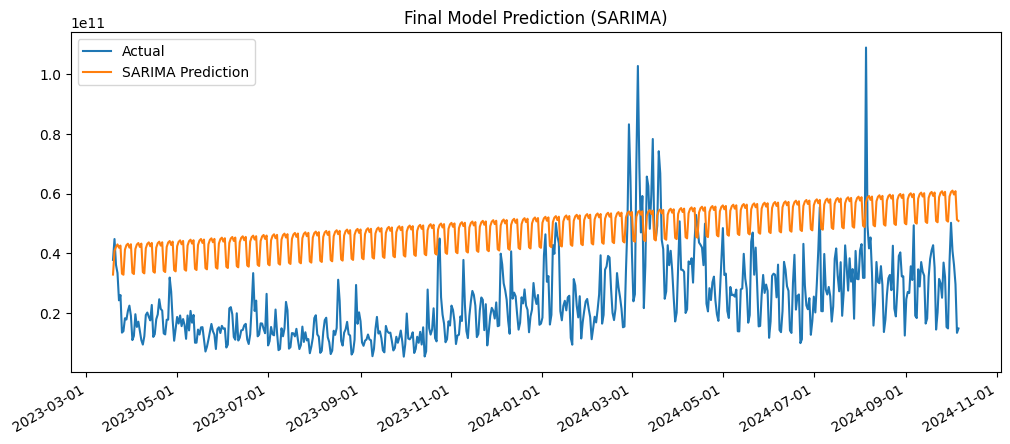

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
ax = plt.gca() # Get the current axes

ax.plot(mdates.date2num(test.index), test.values, label='Actual')
ax.plot(mdates.date2num(pred_sarima.index), pred_sarima.values, label='SARIMA Prediction')

# Explicitly set date formatter and locator to avoid auto-detection issues
formatter = mdates.DateFormatter('%Y-%m-%d') # Format dates as YYYY-MM-DD
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # Automatically pick appropriate tick locations
plt.gcf().autofmt_xdate() # Auto-format for better date label display

plt.legend()
plt.title("Final Model Prediction (SARIMA)")
plt.show()

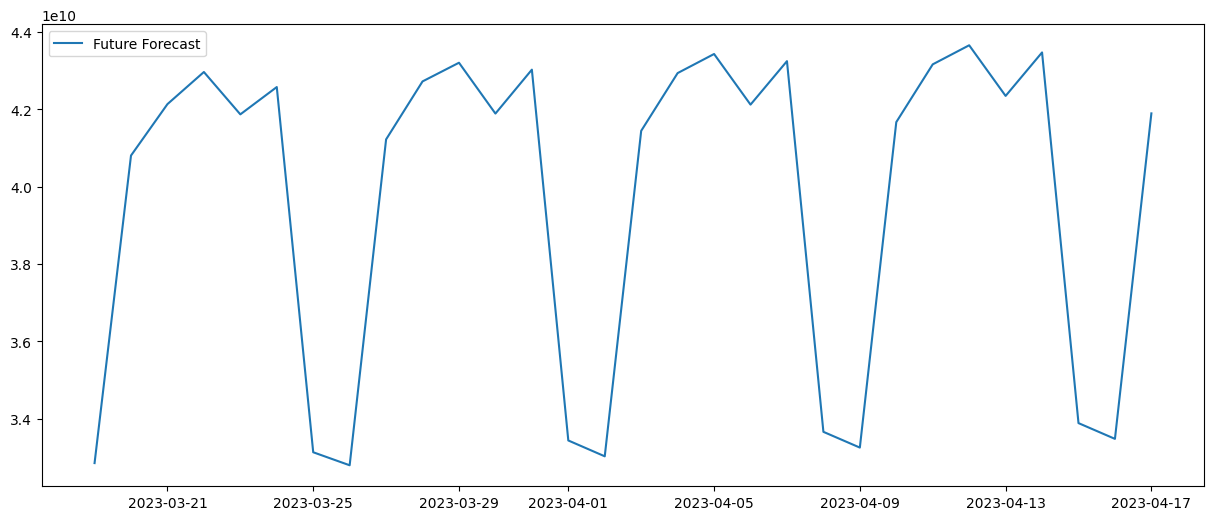

In [40]:
future_pred = model_sarima_fit.forecast(steps=30)

plt.figure(figsize=(15,6))
plt.plot(future_pred, label='Future Forecast')
plt.legend()
plt.show()